In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# PCA
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('/content/donors_descriptive.csv')

# Quick overview
df.head()

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13560 entries, 0 to 13559
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CONTROL_NUMBER               13560 non-null  int64  
 1   CARD_PROM_12                 13297 non-null  float64
 2   CHILDREN                     13289 non-null  float64
 3   DONOR_AGE                    9970 non-null   float64
 4   DONOR_GENDER                 13303 non-null  object 
 5   FILE_CARD_GIFT               13292 non-null  float64
 6   FREQUENCY_STATUS_97NK        13296 non-null  float64
 7   HOME_OWNER                   13292 non-null  object 
 8   INCOME_GROUP                 10273 non-null  float64
 9   LAST_GIFT_AMT                13296 non-null  float64
 10  LIFETIME_CARD_PROM           13289 non-null  float64
 11  LIFETIME_GIFT_AMOUNT         13288 non-null  float64
 12  LIFETIME_GIFT_COUNT          13304 non-null  float64
 13  LIFETIME_MAX_GIF

In [ ]:
df.describe()

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,...,PEP_STAR,PER_CAPITA_INCOME,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,WEALTH_RATING
count,13560.000000,13297.000000,13289.000000,9970.000000,13292.000000,13296.000000,10273.000000,13296.000000,13289.000000,13288.000000,...,13295.000000,13305.000000,13309.000000,13292.000000,13282.000000,13286.000000,13294.000000,13308.000000,13285.000000,7291.000000
mean,96433.007743,5.381058,2.004998,58.870864,5.253405,1.990869,3.922943,16.622972,18.641620,105.010105,...,0.504260,15910.503294,11.730338,15.394193,1.739533,0.231931,3.047406,0.190553,0.900961,5.010274
std,55926.026991,1.313753,1.473369,17.572796,4.812068,1.145976,1.950277,12.930434,8.895656,112.318930,...,0.513613,9215.065476,11.174975,10.725632,1.620748,0.195624,2.123053,0.119483,2.637899,3.010488
min,5.000000,1.000000,-2.341107,0.000000,-10.100341,-1.365242,-1.728999,-21.718664,-7.188999,-245.473199,...,-0.529861,-12761.372943,-22.188242,-16.958872,-3.703178,-0.369805,-3.222148,-0.181767,-7.806416,-3.751835
25%,47975.250000,5.000000,1.000000,46.000000,2.000000,1.000000,2.000000,10.000000,11.000000,41.000000,...,0.000000,10878.000000,5.000000,10.000000,1.000000,0.100000,2.000000,0.105000,0.000000,3.000000
50%,97023.000000,6.000000,2.000000,60.000000,4.000000,2.000000,4.000000,15.000000,18.000000,80.000000,...,1.000000,13893.000000,10.500000,14.250000,1.000000,0.200000,3.000000,0.167000,0.000000,5.000000
75%,145252.750000,6.000000,3.000000,73.000000,8.000000,3.000000,5.000000,20.000000,26.000000,133.000000,...,1.000000,18443.000000,16.000000,20.000000,2.000000,0.333000,4.000000,0.250000,1.000000,8.000000
max,191775.000000,17.000000,6.264709,108.934261,32.000000,5.283869,9.490799,450.000000,55.000000,3775.000000,...,2.003609,174523.000000,260.000000,260.000000,9.000000,1.000000,16.000000,1.000000,22.000000,13.446890


In [ ]:
df['DONOR_AGE'].median()

60.0

In [ ]:
df['DONOR_AGE'].mode()

,DONOR_AGE
0,73.0


In [ ]:
df.columns

Index(['CONTROL_NUMBER', 'CARD_PROM_12', 'CHILDREN', 'DONOR_AGE',
       'DONOR_GENDER', 'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK', 'HOME_OWNER',
       'INCOME_GROUP', 'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM',
       'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT',
       'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_PROM', 'MEDIAN_HOME_VALUE',
       'MEDIAN_HOUSEHOLD_INCOME', 'MONTHS_SINCE_FIRST_GIFT',
       'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP',
       'NUMBER_PROM_12', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3',
       'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME',
       'RECENCY_STATUS_96NK', 'RECENT_AVG_CARD_GIFT_AMT',
       'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_COUNT',
       'RECENT_CARD_RESPONSE_PROP', 'RECENT_RESPONSE_COUNT',
       'RECENT_RESPONSE_PROP', 'RECENT_STAR_STATUS', 'SES', 'URBANICITY',
       'WEALTH_RATING'],
      dtype='object')

In [ ]:
# Numerical
if len(num_cols) > 0:
    imputer_num = SimpleImputer(strategy='mean')
    df[num_cols] = imputer_num.fit_transform(df[num_cols])

# Categorical
if len(cat_cols) > 0:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# Separate numerical & categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

# -------------------------------
# Handle Numerical Columns
# -------------------------------
if len(num_cols) > 0:
    imputer_num = SimpleImputer(strategy='mean')
    df[num_cols] = imputer_num.fit_transform(df[num_cols])

# -------------------------------
# Handle Categorical Columns
# -------------------------------
if len(cat_cols) > 0:
    # Convert to string (avoids mixed type issues)
    df[cat_cols] = df[cat_cols].astype(str)

    imputer_cat = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

# -------------------------------
# Final Check
# -------------------------------
print("\nMissing values after imputation:")
print(df.isnull().sum())

Numerical Columns: ['CONTROL_NUMBER', 'CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK', 'INCOME_GROUP', 'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_PROM', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME', 'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME', 'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_PROP', 'RECENT_RESPONSE_COUNT', 'RECENT_RESPONSE_PROP', 'RECENT_STAR_STATUS', 'WEALTH_RATING']
Categorical Columns: ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']

Missing values after imputation:
CONTROL_NUMBER                 0
CARD_PROM_12                   0
CHILDREN                       0
DONOR

In [ ]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df = df.drop(columns=['CONTROL_NUMBER'])

In [ ]:
df.head()

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,4.0,2.000000,33.000000,1,0.0,1.0,0,5.000000,20.0,9.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,1,4,5.010274
1,3.0,-2.341107,58.870864,0,1.0,1.0,1,3.922943,15.0,6.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,2,2,5.010274
2,4.0,0.000000,74.000000,0,7.0,3.0,0,4.000000,10.0,17.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,0,5,5.010274
3,4.0,4.000000,61.000000,1,13.0,1.0,0,6.000000,11.0,28.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,0,5,5.010274
4,6.0,3.000000,75.000000,1,3.0,4.0,0,3.000000,7.0,9.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,1,1,5.010274


In [ ]:
df.columns

Index(['CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'DONOR_GENDER',
       'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK', 'HOME_OWNER', 'INCOME_GROUP',
       'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT',
       'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT',
       'LIFETIME_PROM', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME',
       'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_GIFT',
       'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12', 'PCT_ATTRIBUTE1',
       'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4',
       'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME',
       'RECENCY_STATUS_96NK', 'RECENT_AVG_CARD_GIFT_AMT',
       'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_COUNT',
       'RECENT_CARD_RESPONSE_PROP', 'RECENT_RESPONSE_COUNT',
       'RECENT_RESPONSE_PROP', 'RECENT_STAR_STATUS', 'SES', 'URBANICITY',
       'WEALTH_RATING'],
      dtype='object')

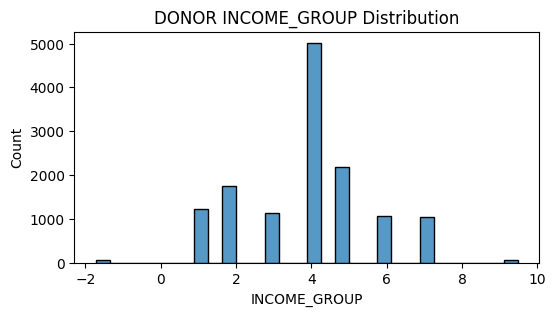

In [ ]:
plt.figure(figsize=(6,3))
sns.histplot(df['INCOME_GROUP'], bins=30)
plt.title("DONOR INCOME_GROUP Distribution")
plt.show()

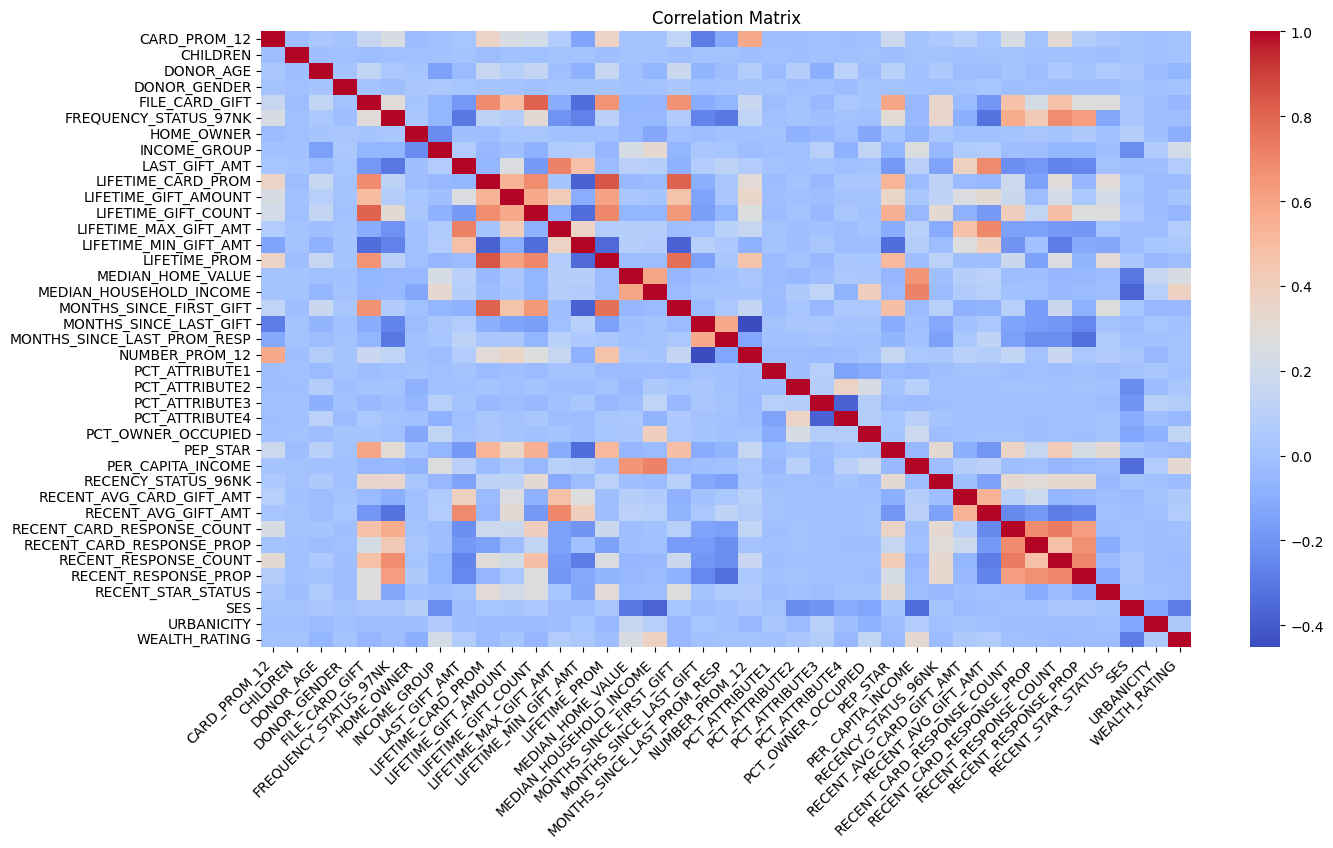

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.xticks(rotation = 45, ha = 'right')
plt.show()

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

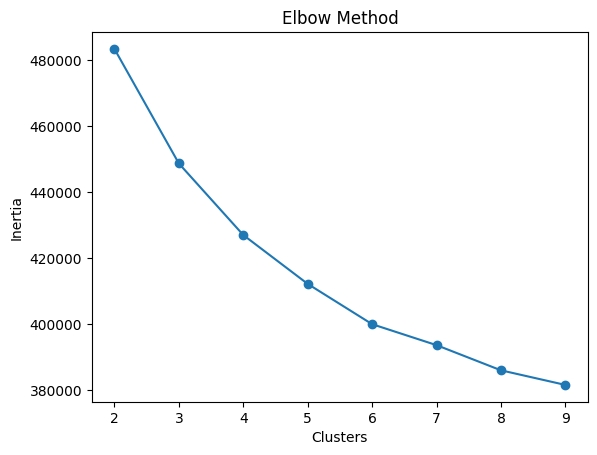

In [ ]:
inertia = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

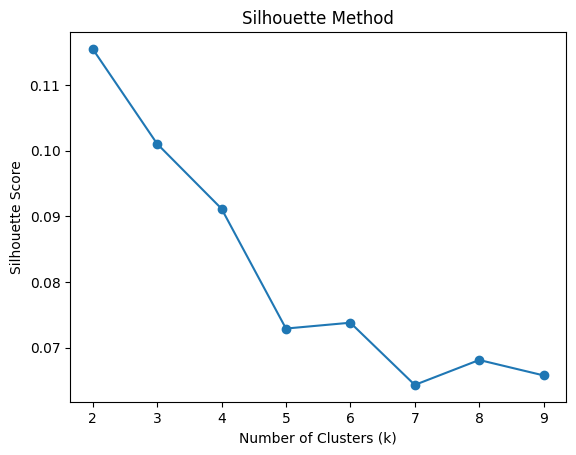

Best K (Silhouette): 2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []

K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    sil_scores.append(score)

# Plot
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

# Best K
best_k = K[sil_scores.index(max(sil_scores))]
print("Best K (Silhouette):", best_k)

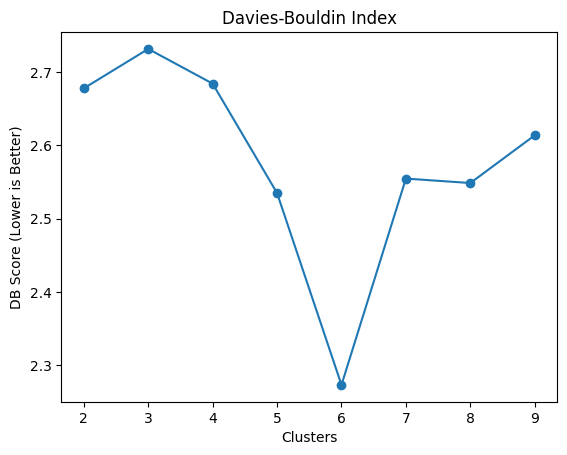

Best K (DB Index): 6


In [ ]:
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    db_scores.append(davies_bouldin_score(df_scaled, labels))

plt.plot(range(2,10), db_scores, marker='o')
plt.title("Davies-Bouldin Index")
plt.xlabel("Clusters")
plt.ylabel("DB Score (Lower is Better)")
plt.show()

best_k = list(range(2,10))[db_scores.index(min(db_scores))]
print("Best K (DB Index):", best_k)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# -------------------------------
# Step 1: Find Best K (Silhouette)
# -------------------------------
sil_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df_scaled)
    sil_scores.append(silhouette_score(df_scaled, labels))

best_k = K[sil_scores.index(max(sil_scores))]
print("Best K (Silhouette):", best_k)

# -------------------------------
# Step 2: Final KMeans Model
# -------------------------------
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(df_scaled)

# Add cluster column
df['Cluster_All'] = clusters

# -------------------------------
# Step 3: Evaluation Metrics
# -------------------------------
sil_score = silhouette_score(df_scaled, clusters)
db_score = davies_bouldin_score(df_scaled, clusters)
ch_score = calinski_harabasz_score(df_scaled, clusters)

print("\nClustering Performance:")
print("Silhouette Score        :", sil_score)
print("Davies-Bouldin Score   :", db_score)
print("Calinski-Harabasz Score:", ch_score)

Best K (Silhouette): 2

Clustering Performance:
Silhouette Score        : 0.11548681768349293
Davies-Bouldin Score   : 2.6777275599549504
Calinski-Harabasz Score: 1674.2039555908302


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

df['Cluster_All'] = clusters

In [ ]:
score = silhouette_score(df_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.09116722883236766


In [ ]:
# for mean
score = silhouette_score(df_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.09116722883236766


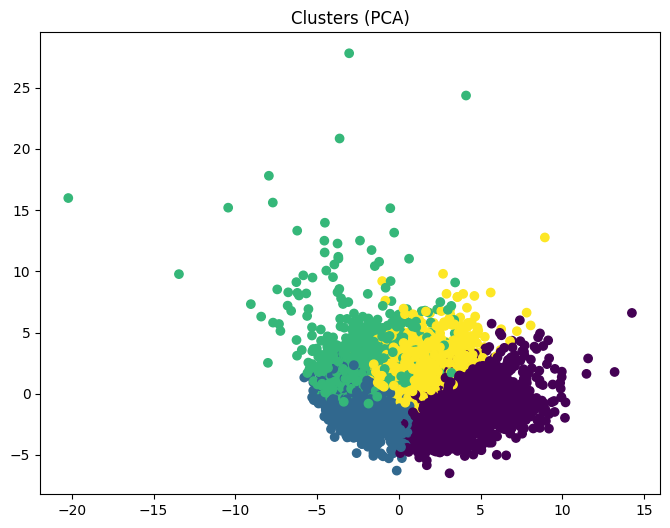

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap='viridis')
plt.title("Clusters (PCA)")
plt.show()

In [ ]:
donation_features = [
    'RECENT_AVG_GIFT_AMT',
    'LIFETIME_GIFT_AMOUNT',
    'LIFETIME_GIFT_COUNT',
    'LAST_GIFT_AMT',
    'RECENT_RESPONSE_COUNT'
]

df_donation = df[donation_features]

In [ ]:
df_donation_scaled = scaler.fit_transform(df_donation)

In [ ]:
kmeans2 = KMeans(n_clusters=3, random_state=42)
clusters2 = kmeans2.fit_predict(df_donation_scaled)

df['Cluster_Donation'] = clusters2

In [ ]:
score2 = silhouette_score(df_donation_scaled, clusters2)
print("Silhouette Score (Donation):", score2)

Silhouette Score (Donation): 0.3517639032022046


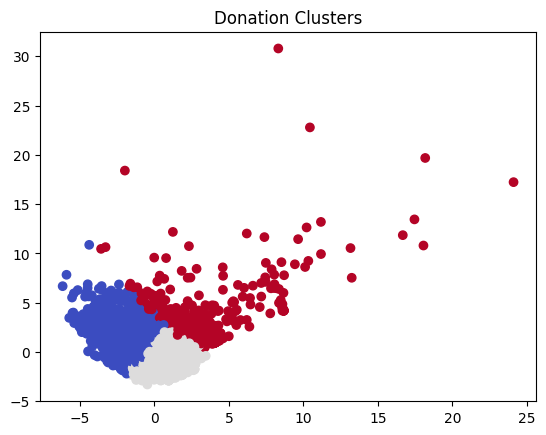

In [ ]:
pca2 = PCA(n_components=2)
pca_data2 = pca2.fit_transform(df_donation_scaled)

plt.scatter(pca_data2[:,0], pca_data2[:,1], c=clusters2, cmap='coolwarm')
plt.title("Donation Clusters")
plt.show()

In [ ]:
cluster_summary = df.groupby('Cluster_All').mean()
cluster_summary

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,Cluster_Donation
Cluster_All,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,5.849778,1.982550,60.314055,0.508088,9.208197,3.376959,0.468471,3.693278,9.717556,22.172422,131.882502,17.154120,12.919762,3.850590,56.653404,916.357210,319.447875,80.741133,16.573629,17.467673,14.145720,0.939282,30.857966,29.369182,32.567764,70.011049,0.926109,14581.646379,3.208650,9.172576,9.235221,3.725865,0.410808,5.836334,0.325941,0.689508,1.038957,2.696600,4.908492,0.127105
1,4.966674,2.022107,56.737271,0.475822,1.775909,1.630630,0.465377,3.867671,17.591705,11.276278,45.122744,3.522476,18.871058,10.951013,28.096217,875.533379,306.551664,38.663300,18.854689,19.158740,11.415505,1.367123,30.361581,30.404767,31.738143,67.239111,0.106220,13955.354378,0.976983,11.891254,16.153423,1.102205,0.220021,2.089688,0.171457,0.014423,1.054352,2.779304,4.867284,0.980271
2,5.586413,2.048653,57.424982,0.545603,3.874503,1.630277,0.300382,5.277261,25.338903,18.866541,124.277539,7.368191,29.199736,10.158810,48.965406,2424.977969,580.442804,68.709044,18.574756,19.514172,13.422476,0.734043,30.966620,31.336830,33.181655,79.022879,0.381899,28257.338540,0.816494,17.051314,22.715065,1.327973,0.168277,2.353289,0.139637,0.481277,0.190606,3.126161,6.949104,1.016384
3,5.525361,1.976174,62.655641,0.506516,7.573079,1.516827,0.471955,3.570236,16.487229,26.233208,157.740911,14.444598,19.767114,4.702830,66.944331,798.629587,289.501070,104.091017,18.444596,19.872117,13.807270,0.860088,30.855145,27.908721,34.274459,68.523709,0.825932,13364.245168,1.126346,10.841953,15.682904,1.123771,0.126426,2.413428,0.127077,2.528319,1.182153,2.665156,4.283121,0.660057


In [ ]:
donation_summary = df.groupby('Cluster_Donation').mean()
donation_summary

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,Cluster_All
Cluster_Donation,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,5.743131,1.990620,61.385593,0.505261,9.363636,2.805777,0.457457,3.734555,10.549376,24.263522,151.866819,18.529218,14.286177,3.941007,62.215322,978.047616,327.112570,90.910858,17.144735,18.316877,14.135483,0.952575,30.822631,29.011856,33.246898,70.025241,0.886407,15036.724781,2.630146,9.676526,10.240143,2.936125,0.316079,5.062282,0.268421,1.353705,1.044373,2.720952,4.855679,1.050549
1,5.189342,2.012148,58.002195,0.494159,3.154302,1.604244,0.439075,4.034594,17.606228,15.623363,68.966091,5.570538,19.259453,8.893737,39.308968,1102.274728,346.943351,57.751233,18.757005,19.316929,12.164165,1.120143,30.609629,30.001853,32.488655,69.652682,0.329289,16104.393575,0.942510,11.613296,16.207187,1.137591,0.192572,2.069455,0.153572,0.629653,0.933578,2.810009,5.057135,1.589327
2,5.937770,2.002968,60.284068,0.574561,5.305007,1.586593,0.453947,4.146592,55.086804,22.156061,331.054035,10.964770,64.270282,18.841568,60.479062,1448.165711,389.394241,78.850134,17.669118,19.917715,15.710405,0.762090,30.738765,29.016244,33.842185,69.981758,0.478978,19447.008515,1.122807,32.985719,48.569200,1.342750,0.159648,2.428587,0.139113,1.212160,0.881579,2.710526,5.453901,2.085526
